In [55]:
import colorsys
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from matplotlib.ticker import MultipleLocator, PercentFormatter


_RGB = ["#D62728", "#2CA02C", "#1F77B4"]  # red, green, blue
_STYLE = {
    "fig_facecolor": "#FFFFFF",
    "ax_facecolor": "#FFFFFF",
    "spine": "#000000",
    "tick": "#000000",
    "label": "#000000",
    "title": "#000000",
    "grid": "#B0B0B0",
    "legend_edge": "#000000",
    "legend_face": "#FFFFFF",
}


def _default_rgb_colors(n_dirs):
    return [_RGB[i % 3] for i in range(n_dirs)]


def _default_linestyles(n_dirs):
    pattern = ["--", "--", "--", "-", "-", "-"]
    return [pattern[i % 6] for i in range(n_dirs)]


def _default_markers(n_dirs):
    pattern = ["^", "^", "^", "o", "o", "o"]
    return [pattern[i % 6] for i in range(n_dirs)]


def _assign_distinct_colors(n_dirs, color_list=None):
    if n_dirs <= 0:
        return []
    if color_list is not None:
        if len(color_list) != n_dirs:
            raise ValueError(
                f"color_list length {len(color_list)} != number of curves {n_dirs}"
            )
        return list(color_list)
    return _default_rgb_colors(n_dirs)


def _parse_result_json(data):
    if isinstance(data, dict) and ("n" in data and "avg_eer" in data):
        n = np.array(data["n"], dtype=float)
        avg_eer = np.array(data["avg_eer"], dtype=float)
        return n, avg_eer, None

    bucket = {}
    for user_block in data.values() if isinstance(data, dict) else []:
        if not isinstance(user_block, dict):
            continue
        for rec in user_block.values():
            if not isinstance(rec, dict):
                continue
            n_val = rec.get("n")
            eer_val = rec.get("EER", rec.get("avg_eer"))
            if n_val is None or eer_val is None:
                continue
            bucket.setdefault(float(n_val), []).append(float(eer_val))

    if not bucket:
        raise ValueError("Unsupported JSON structure for plotting")

    sorted_n = sorted(bucket.keys())
    n = np.array(sorted_n, dtype=float)
    avg_eer = np.array([np.mean(bucket[k]) for k in sorted_n])
    return n, avg_eer, bucket


def _nearest_n_for_event(target_event, n_values, seq_length, shift):
    events = n_values * seq_length + shift
    idx = int(np.argmin(np.abs(events - target_event)))
    return float(n_values[idx])


def _drop_max_eer_outlier(values):
    values = np.asarray(values, dtype=float)
    if len(values) <= 1:
        return values
    return np.delete(values, int(np.argmax(values)))


def _draw_box_at(ax, x, values, color, offset=0, box_width=22, alpha=0.22):
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return None, None

    q1, med, q3 = np.percentile(values, [25, 50, 75])
    vmin, vmax = values.min(), values.max()
    cx = x + offset
    half = box_width / 2

    rect = Rectangle(
        (cx - half, q1),
        box_width,
        q3 - q1,
        facecolor=color,
        edgecolor=color,
        alpha=alpha,
        linewidth=1.0,
        zorder=3,
    )
    ax.add_patch(rect)
    ax.plot([cx - half, cx + half], [med, med], color=color, linewidth=1.2, solid_capstyle="round", zorder=4)
    ax.plot([cx, cx], [vmin, q1], color=color, linewidth=0.9, solid_capstyle="round", zorder=4, alpha=0.9)
    ax.plot([cx, cx], [q3, vmax], color=color, linewidth=0.9, solid_capstyle="round", zorder=4, alpha=0.9)

    cap = box_width * 0.28
    ax.plot([cx - cap, cx + cap], [vmin, vmin], color=color, linewidth=0.9, solid_capstyle="round", zorder=4, alpha=0.9)
    ax.plot([cx - cap, cx + cap], [vmax, vmax], color=color, linewidth=0.9, solid_capstyle="round", zorder=4, alpha=0.9)

    return float(np.mean(values)), float(np.std(values))


def _style_publication_axes(ax, fig):
    """Four-sided box frame + light dashed grid."""
    fig.patch.set_facecolor(_STYLE["fig_facecolor"])
    ax.set_facecolor(_STYLE["ax_facecolor"])

    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color(_STYLE["spine"])
        ax.spines[side].set_linewidth(1.0)

    ax.tick_params(
        axis="both",
        which="major",
        colors=_STYLE["tick"],
        labelsize=10,
        length=4.0,
        width=0.8,
        direction="out",
    )
    ax.grid(
        which="major",
        axis="both",
        linestyle="--",
        color=_STYLE["grid"],
        alpha=0.65,
        linewidth=0.6,
        zorder=0,
    )
    ax.set_axisbelow(True)


def _resolve_ylim_max(ylim_max, all_eer_max):
    """
    ylim_max:
      None -> auto
      0~1  -> fraction (0.18 = 18%)
      >1   -> percent  (18 = 18%)
    """
    if ylim_max is None:
        return float(all_eer_max) * 1.05 if all_eer_max > 0 else 0.05
    y = float(ylim_max)
    if y > 1.0:
        y = y / 100.0
    return y


def plot_eer_publication_style(
    dir_list,
    max_event=650,
    seq_length=120,
    title=None,
    legend_names=None,
    shift_list=None,
    per_user_dir_list=None,
    box_event_positions=(300, 450, 600),
    linestyle_list=None,
    marker_list=None,
    color_list=None,
    show_boxplots=True,
    show_errorbars=True,
    drop_max_eer_outlier=False,
    panel_label=None,
    dataset_name="Balabit",
    figsize=(7.8, 5.2),
    plot_n_set={1, 5, 10, 15},
    x_axis_start_event=0,
    ylim_max=None,
    linewidth=1.35,   # thinner lines; change this if still thick
    markersize=5.0,
):
    dir_list = [Path(d) for d in dir_list]
    n_dirs = len(dir_list)

    if legend_names is not None and len(legend_names) != n_dirs:
        raise ValueError("legend_names must match number of directories")

    if shift_list is None:
        shift_list = [0] * n_dirs
    if len(shift_list) != n_dirs:
        raise ValueError("shift_list must match number of directories")

    if per_user_dir_list is None:
        per_user_dir_list = dir_list
    else:
        if len(per_user_dir_list) != n_dirs:
            raise ValueError("per_user_dir_list must match number of directories")
        per_user_dir_list = [
            Path(d) if d is not None else None
            for d in per_user_dir_list
        ]

    color_list = _assign_distinct_colors(n_dirs, color_list=color_list)
    if linestyle_list is None:
        linestyle_list = _default_linestyles(n_dirs)
    else:
        linestyle_list = list(linestyle_list)[:n_dirs]
        if len(linestyle_list) < n_dirs:
            linestyle_list = linestyle_list + ["-"] * (n_dirs - len(linestyle_list))

    if marker_list is None:
        marker_list = _default_markers(n_dirs)
    else:
        marker_list = list(marker_list)[:n_dirs]
        if len(marker_list) < n_dirs:
            marker_list = marker_list + ["o"] * (n_dirs - len(marker_list))

    fig, ax = plt.subplots(figsize=figsize, dpi=140)
    _style_publication_axes(ax, fig)
    has_any_curve = False
    all_eer_max = 0.0
    series_meta = []

    for dir_idx, result_dir in enumerate(dir_list):
        color = color_list[dir_idx]
        linestyle = linestyle_list[dir_idx]
        marker = marker_list[dir_idx]
        shift = shift_list[dir_idx]
        legend_label = legend_names[dir_idx] if legend_names else result_dir.name
        per_user_dir = per_user_dir_list[dir_idx]
        first_plot = True

        for json_file in result_dir.glob("*.json"):
            try:
                with open(json_file, "r", encoding="utf-8") as f:
                    data = json.load(f)

                n, avg_eer, user_bucket = _parse_result_json(data)

                if per_user_dir is not None:
                    per_user_file = per_user_dir / json_file.name
                    if per_user_file.exists() and per_user_file != json_file:
                        with open(per_user_file, "r", encoding="utf-8") as f:
                            _, _, user_bucket = _parse_result_json(json.load(f))

                if plot_n_set is not None:
                    mask = np.isin(n, list(plot_n_set))
                    n = n[mask]
                    avg_eer = avg_eer[mask]
                    if user_bucket is not None:
                        keep = set(float(x) for x in n.tolist())
                        user_bucket = {k: v for k, v in user_bucket.items() if float(k) in keep}

                events = n * seq_length + shift
                mask = events <= max_event
                events = events[mask]
                avg_eer = avg_eer[mask]
                n = n[mask]

                if len(events) == 0:
                    continue

                ax.plot(
                    events,
                    avg_eer,
                    linestyle=linestyle,
                    linewidth=linewidth,
                    marker=marker,
                    markersize=markersize,
                    markerfacecolor=color,
                    markeredgecolor=color,
                    markeredgewidth=0.8,
                    color=color,
                    alpha=0.95,
                    solid_capstyle="round",
                    solid_joinstyle="round",
                    label=legend_label if first_plot else None,
                    zorder=5,
                )

                has_any_curve = True
                all_eer_max = max(all_eer_max, float(np.nanmax(avg_eer)))
                series_meta.append({
                    "color": color,
                    "n": n,
                    "events": events,
                    "avg_eer": avg_eer,
                    "user_bucket": user_bucket,
                    "shift": shift,
                })
                first_plot = False

            except Exception as e:
                print(f"[ERROR] {json_file}: {e}")

    if not has_any_curve:
        raise ValueError("No valid curves were plotted. Check directory path and JSON format.")

    if show_boxplots or show_errorbars:
        n_series = len(series_meta)
        box_width = 16
        box_gap = 10
        if n_series > 1:
            step = box_width + box_gap
            total_span = step * (n_series - 1)
            box_offsets = np.linspace(-total_span / 2, total_span / 2, n_series)
        else:
            box_offsets = np.array([0.0])

        for box_event in box_event_positions:
            if box_event > max_event:
                continue
            for s_idx, meta in enumerate(series_meta):
                if meta["user_bucket"] is None:
                    continue
                n_key = _nearest_n_for_event(
                    box_event, meta["n"], seq_length, meta["shift"]
                )
                if n_key not in meta["user_bucket"]:
                    if int(n_key) in meta["user_bucket"]:
                        n_key = int(n_key)
                    else:
                        continue

                user_eers = meta["user_bucket"][n_key]
                if drop_max_eer_outlier:
                    user_eers = _drop_max_eer_outlier(user_eers)
                x_pos = n_key * seq_length + meta["shift"]
                offset = box_offsets[s_idx] if show_boxplots else 0.0

                if show_boxplots:
                    mean_val, std_val = _draw_box_at(
                        ax, x_pos, user_eers, meta["color"],
                        offset=offset, box_width=box_width,
                    )
                else:
                    mean_val = float(np.mean(user_eers))
                    std_val = float(np.std(user_eers))

                if show_errorbars and mean_val is not None and std_val is not None:
                    ax.errorbar(
                        x_pos + offset, mean_val, yerr=std_val,
                        fmt="none", ecolor=meta["color"],
                        elinewidth=1.0, capsize=3.0, capthick=1.0,
                        alpha=0.9, zorder=6,
                    )

    ax.set_xlim(left=float(x_axis_start_event))
    y_top = _resolve_ylim_max(ylim_max, all_eer_max)
    ax.set_ylim(bottom=0, top=y_top)

    if y_top <= 1.0 and all_eer_max <= 1.0:
        ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=2))
        ax.yaxis.set_major_locator(MultipleLocator(0.01))
    else:
        ax.yaxis.set_major_formatter(PercentFormatter(100.0, decimals=2))
        ax.yaxis.set_major_locator(MultipleLocator(1.0))

    ax.xaxis.set_major_locator(MultipleLocator(100))
    ax.set_xlabel("Number of Events", fontsize=12, color=_STYLE["label"], labelpad=8)
    ax.set_ylabel("Mean EER (%)", fontsize=12, color=_STYLE["label"], labelpad=8)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha="right")

    if title:
        ax.set_title(title, fontsize=13, weight="bold", color=_STYLE["title"], pad=10)
    else:
        ax.set_title(
            f"{dataset_name}: Mean EER vs Mean Number of Events",
            fontsize=13, weight="bold", color=_STYLE["title"], pad=10,
        )

    legend = ax.legend(
        loc="upper right",
        fontsize=9,
        frameon=True,
        fancybox=False,
        edgecolor=_STYLE["legend_edge"],
        facecolor=_STYLE["legend_face"],
        framealpha=1.0,
        markerscale=0.9,
        handlelength=2.2,
        handletextpad=0.6,
        borderpad=0.6,
        labelspacing=0.4,
    )
    legend.get_frame().set_linewidth(0.8)

    if panel_label:
        fig.text(
            0.5, -0.02, panel_label,
            ha="center", va="top", fontsize=12,
            color=_STYLE["label"], weight="medium",
        )

    _style_publication_axes(ax, fig)
    fig.tight_layout()
    plt.show()

## MultiCNN


## Balabit


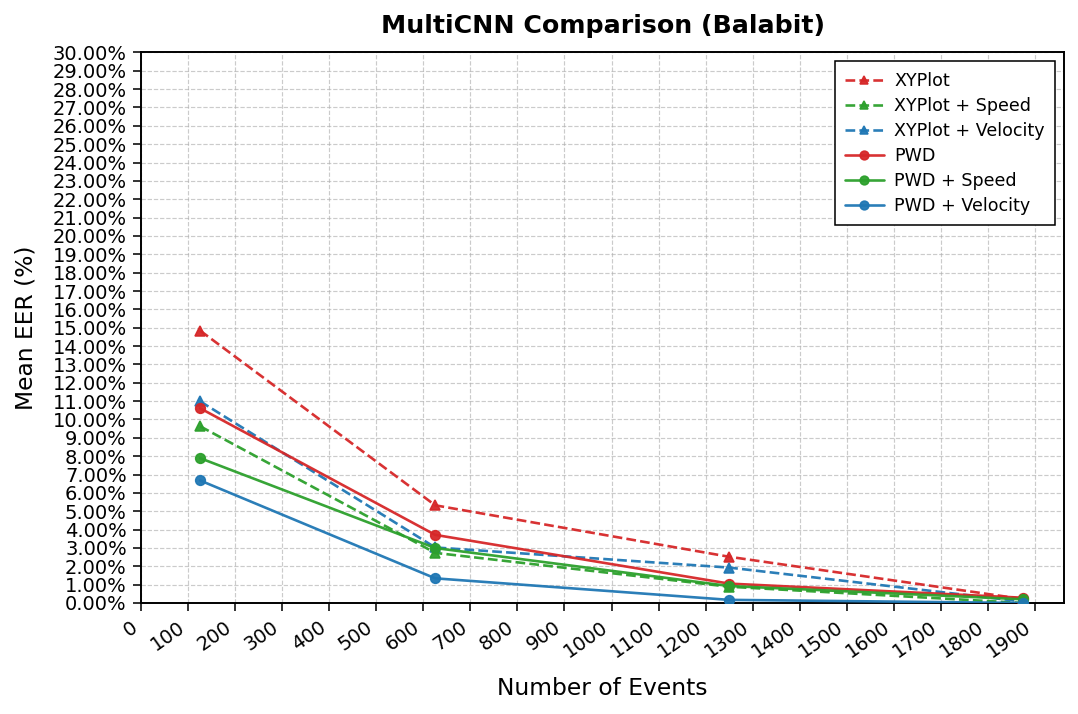

In [56]:
dir_list = [
    "Results/Balabit/CNN/XYPlot_c",
    "Results/Balabit/CNN/XYPlot_velocity_c",
    "Results/Balabit/CNN/XYPlot_vxvy_c",
    "Results/Balabit/CNN/PairWise+Chunk",
    "Results/Balabit/CNN/PairWise_velocity+Chunk",
    "Results/Balabit/CNN/PairWise_vxvy+Chunk"
]

per_user_dir_list = [
    "Results/Balabit/CNN/per-userXYPlot_c",
    "Results/Balabit/CNN/per-userXYPlot_velocity_c",
    "Results/Balabit/CNN/per-userXYPlot_vxvy_c",
    "Results/Balabit/CNN/per-userPairWise+Chunk",
    "Results/Balabit/CNN/per-userPairWise_velocity+Chunk",
    "Results/Balabit/CNN/per-userPairWise_vxvy+Chunk"
]

plot_eer_publication_style(
    dir_list,
    per_user_dir_list=per_user_dir_list,
    max_event=2000,
    seq_length=125,
    title="MultiCNN Comparison (Balabit)",
    legend_names=[
        "XYPlot",
        "XYPlot + Speed",
        "XYPlot + Velocity",
        "PWD",
        "PWD + Speed",
        "PWD + Velocity"
    ],
    shift_list=[0, 0, 0, 0, 0, 0],
    marker_list=["^", "^", "^", "o", "o", "o"],
    linestyle_list=["--", "--", "--", "-", "-", "-"],
    color_list=[
    "#D62728",  # XYPlot - red
    "#2CA02C",  # XYPlot Absolute Velocity - green
    "#1F77B4",  # XYPlot Directional Velocity - blue
    "#D62728",  # PWD - red
    "#2CA02C",  # PWD + Speed - green
    "#1F77B4",  # PWD + Velocity - blue
],
    box_event_positions=(600, 1200, 1800),
    show_boxplots=False,
    show_errorbars=False,
    ylim_max=30
)


## TWOS

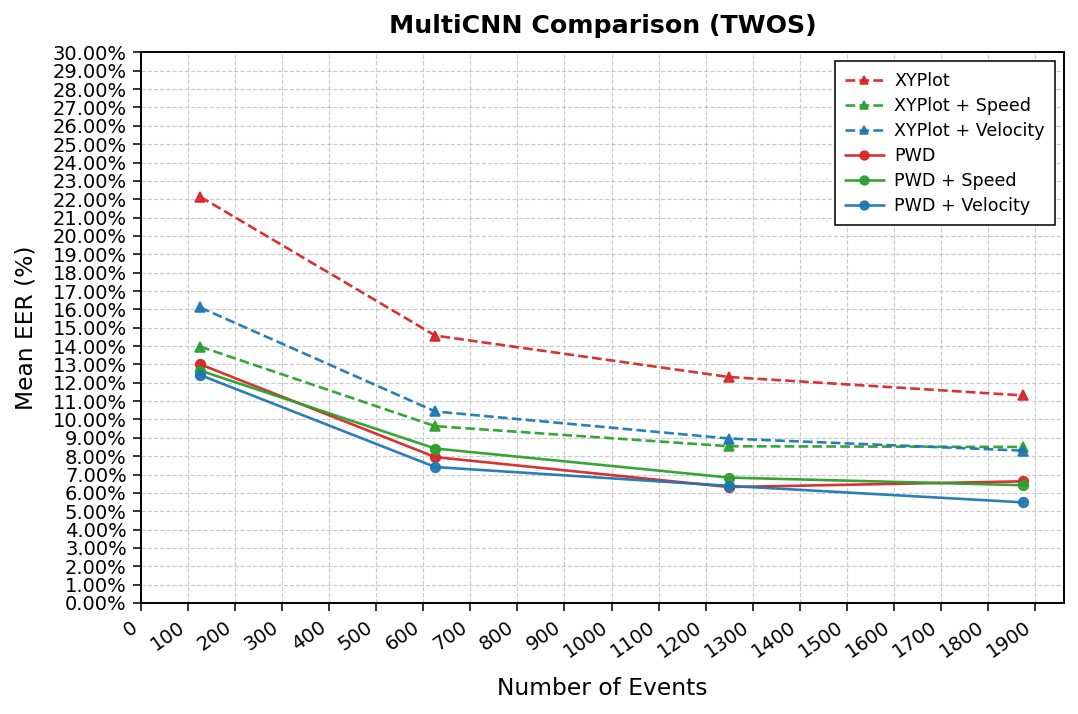

In [57]:
dir_list = [
    "Results/TWOS/CNN/XYPlot",
    "Results/TWOS/CNN/XYPlot_velocity",
    "Results/TWOS/CNN/XYPlot_vxvy",
    "Results/TWOS/CNN/PairWise",
    "Results/TWOS/CNN/PairWise_velocity",
    "Results/TWOS/CNN/PairWise_vxvy"
]

per_user_dir_list = [
    "Results/TWOS/CNN/per-userXYPlot",
    "Results/TWOS/CNN/per-userXYPlot_velocity",
    "Results/TWOS/CNN/per-userXYPlot_vxvy",
    "Results/TWOS/CNN/per-userPairWise",
    "Results/TWOS/CNN/per-userPairWise_velocity",
    "Results/TWOS/CNN/per-userPairWise_vxvy"
]

plot_eer_publication_style(
    dir_list,
    per_user_dir_list=per_user_dir_list,
    max_event=2000,
    seq_length=125,
    title="MultiCNN Comparison (TWOS)",
    legend_names=[
        "XYPlot",
        "XYPlot + Speed",
        "XYPlot + Velocity",
        "PWD",
        "PWD + Speed",
        "PWD + Velocity"
    ],
    shift_list=[0, 0, 0, 0, 0, 0],
    marker_list=["^", "^", "^", "o", "o", "o"],
    linestyle_list=["--", "--", "--", "-", "-", "-"],
    color_list=[
    "#D62728",  # XYPlot - red
    "#2CA02C",  # XYPlot Absolute Velocity - green
    "#1F77B4",  # XYPlot Directional Velocity - blue
    "#D62728",  # PWD - red
    "#2CA02C",  # PWD + Speed - green
    "#1F77B4",  # PWD + Velocity - blue
],
    box_event_positions=(600, 1200, 1800),
    show_boxplots=False,
    show_errorbars=False,
    ylim_max=30
)

## ChaoShen

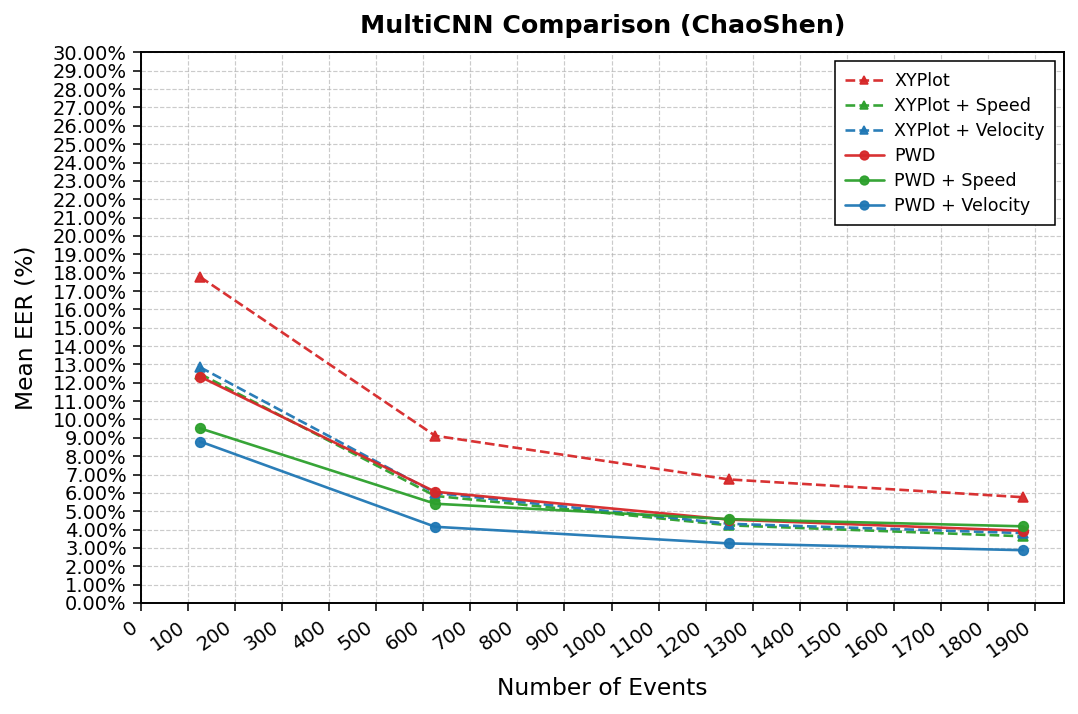

In [58]:
dir_list = [
    "Results/ChaoShen/CNN/XYPlot",
    "Results/ChaoShen/CNN/XYPlot_velocity",
    "Results/ChaoShen/CNN/XYPlot_vxvy",
    "Results/ChaoShen/CNN/PairWise+Chunk",
    "Results/ChaoShen/CNN/PairWise_velocity+Chunk",
    "Results/ChaoShen/CNN/PairWise_vxvy+Chunk"
]

per_user_dir_list = [
    "Results/ChaoShen/CNN/per-userXYPlot",
    "Results/ChaoShen/CNN/per-userXYPlot_velocity",
    "Results/ChaoShen/CNN/per-userXYPlot_vxvy",
    "Results/ChaoShen/CNN/per-userPairWise",
    "Results/ChaoShen/CNN/per-userPairWise_velocity",
    "Results/ChaoShen/CNN/per-userPairWise_vxvy"
]

plot_eer_publication_style(
    dir_list,
    per_user_dir_list=per_user_dir_list,
    max_event=2000,
    seq_length=125,
    title="MultiCNN Comparison (ChaoShen)",
    legend_names=[
        "XYPlot",
        "XYPlot + Speed",
        "XYPlot + Velocity",
        "PWD",
        "PWD + Speed",
        "PWD + Velocity"
    ],
    shift_list=[0, 0, 0, 0, 0, 0],
    marker_list=["^", "^", "^", "o", "o", "o"],
    linestyle_list=["--", "--", "--", "-", "-", "-"],
    color_list=[
    "#D62728",  # XYPlot - red
    "#2CA02C",  # XYPlot Absolute Velocity - green
    "#1F77B4",  # XYPlot Directional Velocity - blue
    "#D62728",  # PWD - red
    "#2CA02C",  # PWD + Speed - green
    "#1F77B4",  # PWD + Velocity - blue
],
    box_event_positions=(600, 1200, 1800),
    show_boxplots=False,
    show_errorbars=False,
    ylim_max=30
)

## DFL

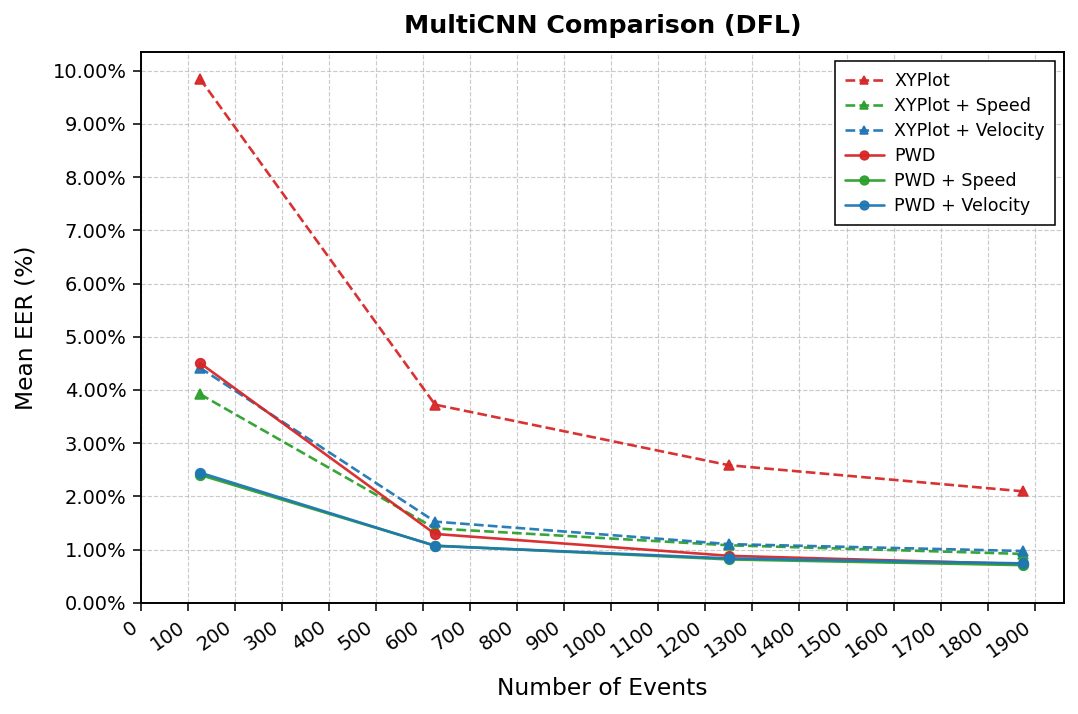

In [64]:
dir_list = [
    "Results/DFL/CNN/XYPlot",
    "Results/DFL/CNN/XYPlot_velocity",
    "Results/DFL/CNN/XYPlot_vxvy",
    "Results/DFL/CNN/PairWise+Chunk",
    "Results/DFL/CNN/PairWise_velocity+Chunk",
    "Results/DFL/CNN/PairWise_vxvy+Chunk"
]

per_user_dir_list = [
    "Results/DFL/CNN/per-userXYPlot",
    "Results/DFL/CNN/per-userXYPlot_velocity",
    "Results/DFL/CNN/per-userXYPlot_vxvy",
    "Results/DFL/CNN/per-userPairWise",
    "Results/DFL/CNN/per-userPairWise_velocity",
    "Results/DFL/CNN/per-userPairWise_vxvy"
]

plot_eer_publication_style(
    dir_list,
    per_user_dir_list=per_user_dir_list,
    max_event=2000,
    seq_length=125,
    title="MultiCNN Comparison (DFL)",
    legend_names=[
        "XYPlot",
        "XYPlot + Speed",
        "XYPlot + Velocity",
        "PWD",
        "PWD + Speed",
        "PWD + Velocity"
    ],
    shift_list=[0, 0, 0, 0, 0, 0],
    marker_list=["^", "^", "^", "o", "o", "o"],
    linestyle_list=["--", "--", "--", "-", "-", "-"],
    color_list=[
    "#D62728",  # XYPlot - red
    "#2CA02C",  # XYPlot Absolute Velocity - green
    "#1F77B4",  # XYPlot Directional Velocity - blue
    "#D62728",  # PWD - red
    "#2CA02C",  # PWD + Speed - green
    "#1F77B4",  # PWD + Velocity - blue
],
    box_event_positions=(600, 1200, 1800),
    show_boxplots=False,
    show_errorbars=False
)

## MultiViT

## Balabit

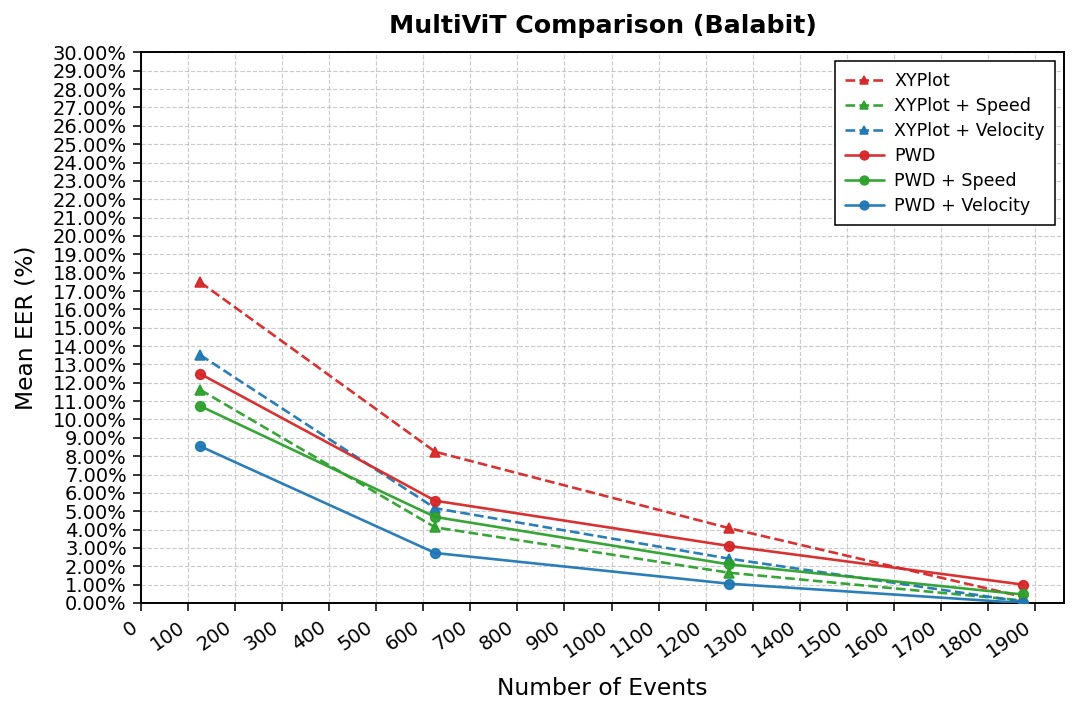

In [60]:
dir_list = [
    "Results/Balabit/ViT/XYPlot",
    "Results/Balabit/ViT/XYPlot_velocity",
    "Results/Balabit/ViT/XYPlot_vxvy",
    "Results/Balabit/ViT/PairWise",
    "Results/Balabit/ViT/PairWise_velocity",
    "Results/Balabit/ViT/PairWise_vxvy"
]

per_user_dir_list = [
    "Results/Balabit/ViT/per-userXYPlot",
    "Results/Balabit/ViT/per-userXYPlot_velocity",
    "Results/Balabit/ViT/per-userXYPlot_vxvy",
    "Results/Balabit/ViT/per-userPairWise",
    "Results/Balabit/ViT/per-userPairWise_velocity",
    "Results/Balabit/ViT/per-userPairWise_vxvy"
]

plot_eer_publication_style(
    dir_list,
    per_user_dir_list=per_user_dir_list,
    max_event=2000,
    seq_length=125,
    title="MultiViT Comparison (Balabit)",
    legend_names=[
        "XYPlot",
        "XYPlot + Speed",
        "XYPlot + Velocity",
        "PWD",
        "PWD + Speed",
        "PWD + Velocity"
    ],
    shift_list=[0, 0, 0, 0, 0, 0],
    marker_list=["^", "^", "^", "o", "o", "o"],
    linestyle_list=["--", "--", "--", "-", "-", "-"],
    color_list=[
    "#D62728",  # XYPlot - red
    "#2CA02C",  # XYPlot Absolute Velocity - green
    "#1F77B4",  # XYPlot Directional Velocity - blue
    "#D62728",  # PWD - red
    "#2CA02C",  # PWD + Speed - green
    "#1F77B4",  # PWD + Velocity - blue
],
    box_event_positions=(600, 1200, 1800),
    show_boxplots=False,
    show_errorbars=False,
    ylim_max=30
)

## TWOS

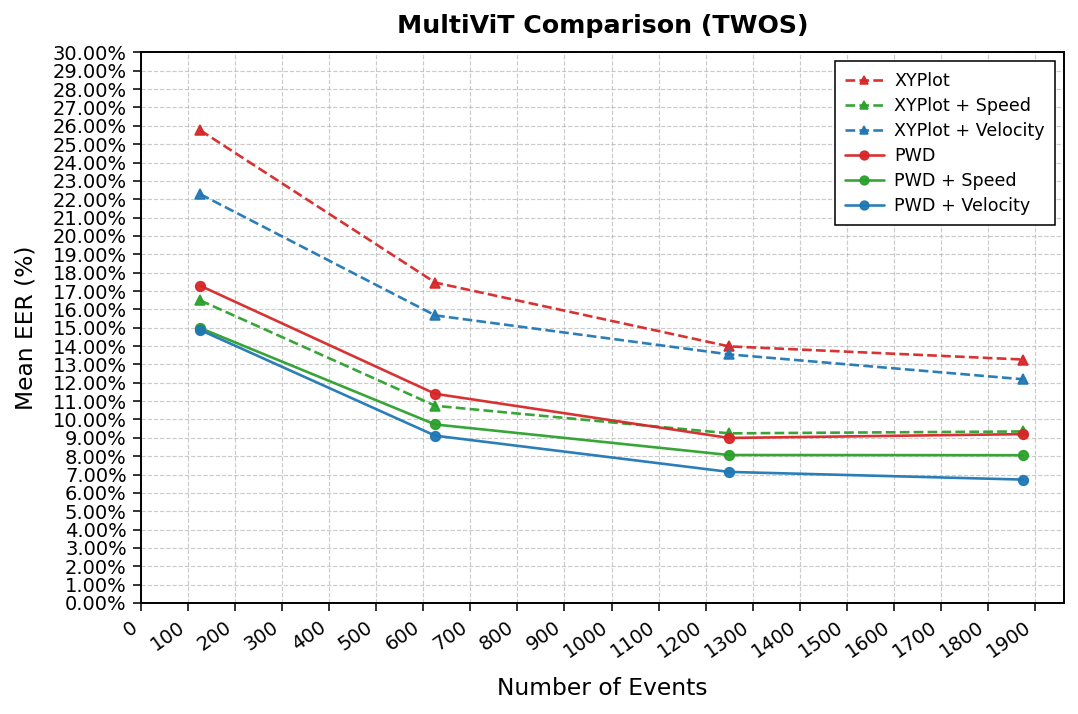

In [61]:
dir_list = [
    "Results/TWOS/ViT/XYPlot",
    "Results/TWOS/ViT/XYPlot_velocity",
    "Results/TWOS/ViT/XYPlot_vxvy",
    "Results/TWOS/ViT/PairWise",
    "Results/TWOS/ViT/PairWise_velocity",
    "Results/TWOS/ViT/PairWise_vxvy"
]

per_user_dir_list = [
    "Results/TWOS/ViT/per-userXYPlot",
    "Results/TWOS/ViT/per-userXYPlot_velocity",
    "Results/TWOS/ViT/per-userXYPlot_vxvy",
    "Results/TWOS/ViT/per-userPairWise",
    "Results/TWOS/ViT/per-userPairWise_velocity",
    "Results/TWOS/ViT/per-userPairWise_vxvy"
]

plot_eer_publication_style(
    dir_list,
    per_user_dir_list=per_user_dir_list,
    max_event=2000,
    seq_length=125,
    title="MultiViT Comparison (TWOS)",
    legend_names=[
        "XYPlot",
        "XYPlot + Speed",
        "XYPlot + Velocity",
        "PWD",
        "PWD + Speed",
        "PWD + Velocity"
    ],
    shift_list=[0, 0, 0, 0, 0, 0],
    marker_list=["^", "^", "^", "o", "o", "o"],
    linestyle_list=["--", "--", "--", "-", "-", "-"],
    color_list=[
    "#D62728",  # XYPlot - red
    "#2CA02C",  # XYPlot Absolute Velocity - green
    "#1F77B4",  # XYPlot Directional Velocity - blue
    "#D62728",  # PWD - red
    "#2CA02C",  # PWD + Speed - green
    "#1F77B4",  # PWD + Velocity - blue
],
    box_event_positions=(600, 1200, 1800),
    show_boxplots=False,
    show_errorbars=False,
    ylim_max=30
)

## ChaoShen

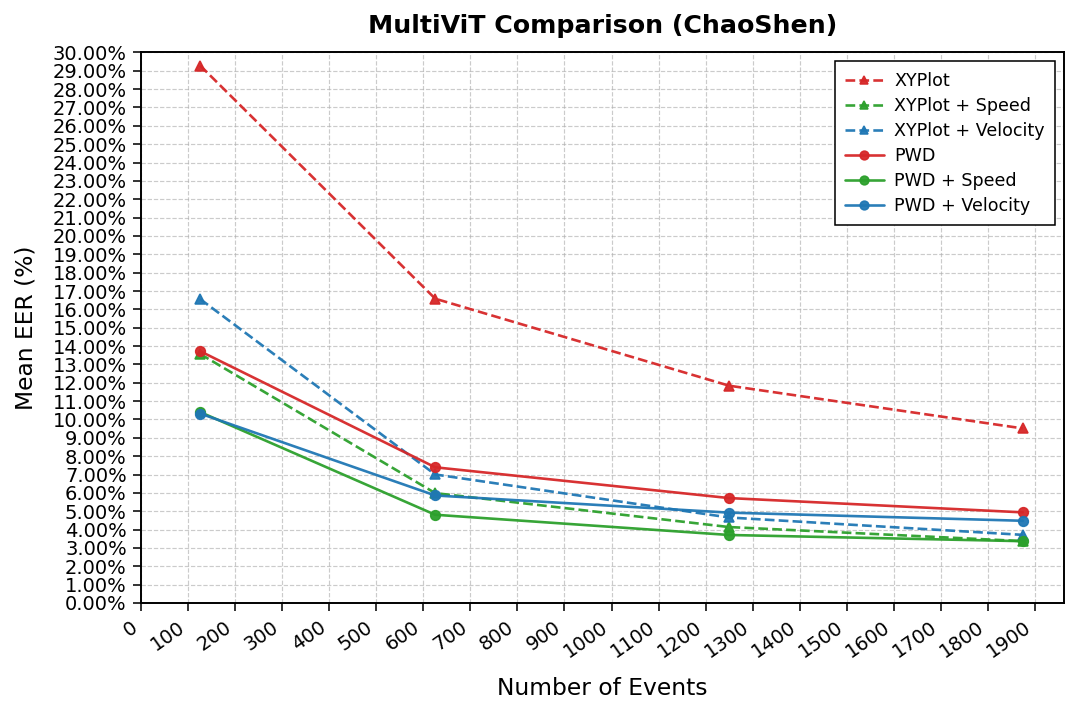

In [62]:
dir_list = [
    "Results/ChaoShen/ViT/XYPlot",
    "Results/ChaoShen/ViT/XYPlot_velocity",
    "Results/ChaoShen/ViT/XYPlot_vxvy",
    "Results/ChaoShen/ViT/PairWise",
    "Results/ChaoShen/ViT/PairWise_velocity",
    "Results/ChaoShen/ViT/PairWise_vxvy"
]

per_user_dir_list = [
    "Results/ChaoShen/ViT/per-userXYPlot",
    "Results/ChaoShen/ViT/per-userXYPlot_velocity",
    "Results/ChaoShen/ViT/per-userXYPlot_vxvy",
    "Results/ChaoShen/ViT/per-userPairWise",
    "Results/ChaoShen/ViT/per-userPairWise_velocity",
    "Results/ChaoShen/ViT/per-userPairWise_vxvy"
]

plot_eer_publication_style(
    dir_list,
    per_user_dir_list=per_user_dir_list,
    max_event=2000,
    seq_length=125,
    title="MultiViT Comparison (ChaoShen)",
    legend_names=[
        "XYPlot",
        "XYPlot + Speed",
        "XYPlot + Velocity",
        "PWD",
        "PWD + Speed",
        "PWD + Velocity"
    ],
    shift_list=[0, 0, 0, 0, 0, 0],
    marker_list=["^", "^", "^", "o", "o", "o"],
    linestyle_list=["--", "--", "--", "-", "-", "-"],
    color_list=[
    "#D62728",  # XYPlot - red
    "#2CA02C",  # XYPlot Absolute Velocity - green
    "#1F77B4",  # XYPlot Directional Velocity - blue
    "#D62728",  # PWD - red
    "#2CA02C",  # PWD + Speed - green
    "#1F77B4",  # PWD + Velocity - blue
],
    box_event_positions=(600, 1200, 1800),
    show_boxplots=False,
    show_errorbars=False,
    ylim_max=30
)

## DFL

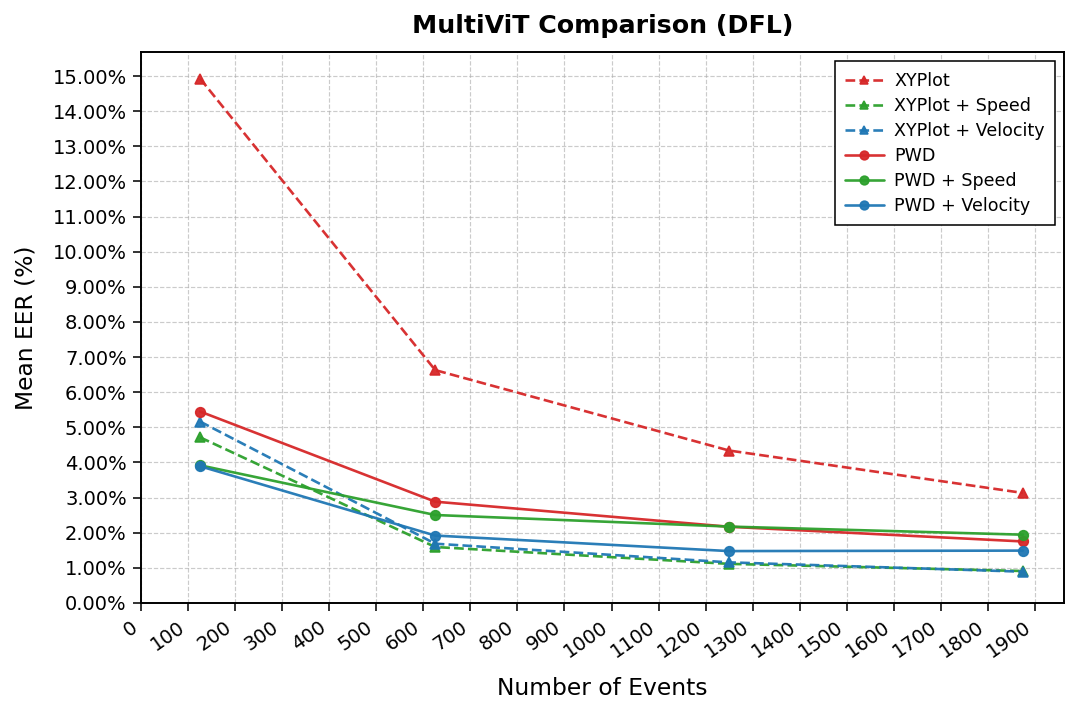

In [65]:
from pathlib import Path
import json as _json
import numpy as _np

dir_list = [
    "Results/DFL/ViT/XYPlot",
    "Results/DFL/ViT/XYPlot_velocity",
    "Results/DFL/ViT/XYPlot_vxvy",
    "Results/DFL/ViT/PairWise",
    "Results/DFL/ViT/PairWise_velocity",
    "Results/DFL/ViT/PairWise_vxvy"
]

per_user_dir_list = [
    "Results/DFL/ViT/per-userXYPlot",
    "Results/DFL/ViT/per-userXYPlot_velocity",
    "Results/DFL/ViT/per-userXYPlot_vxvy",
    "Results/DFL/ViT/per-userPairWise",
    "Results/DFL/ViT/per-userPairWise_velocity",
    "Results/DFL/ViT/per-userPairWise_vxvy"
]

plot_eer_publication_style(
    dir_list,
    per_user_dir_list=per_user_dir_list,
    max_event=2000,
    seq_length=125,
    title="MultiViT Comparison (DFL)",
    legend_names=[
        "XYPlot",
        "XYPlot + Speed",
        "XYPlot + Velocity",
        "PWD",
        "PWD + Speed",
        "PWD + Velocity"
    ],
    shift_list=[0, 0, 0, 0, 0, 0],
    marker_list=["^", "^", "^", "o", "o", "o"],
    linestyle_list=["--", "--", "--", "-", "-", "-"],
    color_list=[
    "#D62728",  # XYPlot - red
    "#2CA02C",  # XYPlot Absolute Velocity - green
    "#1F77B4",  # XYPlot Directional Velocity - blue
    "#D62728",  # PWD - red
    "#2CA02C",  # PWD + Speed - green
    "#1F77B4",  # PWD + Velocity - blue
],
    box_event_positions=(600, 1200, 1800),
    show_boxplots=False,
    show_errorbars=False
)
